# Pembacaan 2 File Vernier Respiratory Belt CSV — RR Ground Truth Last 180 Seconds

Notebook ini dibuat khusus untuk membaca dua file CSV Vernier berikut:

- Object 1: `D:\DATASET PENULISAN BUKU TA\PEMBACAAN VERNIER (SUBJECT 1)\Vernier - 5_11 - .csv`
- Object 2: `D:\DATASET PENULISAN BUKU TA\PEMBACAAN VERNIER (SUBJECT 2)\Vernier - 5_11 - .csv`

Metode yang digunakan:

\[
t_{start}=t_{akhir}-180\ detik
\]

\[
t_{end}=t_{akhir}
\]

Jadi RR ground truth dihitung dari **3 menit terakhir sebelum tombol stop**.

Output utama:

- `RR_PeakCount_Last180_bpm`
- `RR_FFT_Last180_bpm`
- CSV summary dan time-series hasil potongan 180 detik terakhir


In [1]:
# ============================================================
# 1. INPUT FILE CSV VERNIER RESPIRATORY BELT
# ============================================================

VERNIER_CSV_OBJECT_1 = r"C:\Users\AFI\Downloads\respirasense_bpm_20260622_150512.csv"
VERNIER_CSV_OBJECT_2 = r"D:\DATASET PENULISAN BUKU TA\PEMBACAAN VERNIER (SUBJECT 1)\Vernier - 5_11 - 17.58.csv"

NAMA_OBJECT_1 = "Object 1"
NAMA_OBJECT_2 = "Object 2"

# Durasi radar = 3 menit = 180 detik
TARGET_DURATION_S = 180

# Jika kolom otomatis salah, isi manual nama kolomnya di sini.
# Biarkan None dulu.
TIME_COLUMN_OBJECT_1 = None
SIGNAL_COLUMN_OBJECT_1 = None

TIME_COLUMN_OBJECT_2 = None
SIGNAL_COLUMN_OBJECT_2 = None

# Band respirasi untuk FFT
RR_MIN_HZ = 0.08   # 4.8 bpm
RR_MAX_HZ = 0.70   # 42 bpm

# Parameter deteksi peak napas
MIN_PEAK_DISTANCE_S = 1.5
PEAK_PROMINENCE = 0.25

# Export
EXPORT_CSV = True
EXPORT_FOLDER_NAME = "export_vernier_rr_last180_17_58"


In [2]:
# ============================================================
# 2. IMPORT LIBRARY
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import find_peaks, butter, sosfiltfilt, detrend
from scipy.fft import rfft, rfftfreq
from IPython.display import display

plt.rcParams["figure.figsize"] = (11, 4)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 220)


In [3]:
# ============================================================
# 3. CEK FILE
# ============================================================

def check_file_exists(file_path):
    p = Path(file_path)
    print("=" * 100)
    print("Path:", p)
    print("File ada?", p.exists())

    if not p.exists():
        folder = p.parent
        print("\nFolder:", folder)
        print("Folder ada?", folder.exists())

        if folder.exists():
            print("\nDaftar file CSV dalam folder tersebut:")
            csv_files = sorted(folder.glob("*.csv"))
            if len(csv_files) == 0:
                print("Tidak ada file .csv dalam folder.")
            else:
                for i, f in enumerate(csv_files, start=1):
                    print(f"{i:02d}. {repr(f.name)}")
        else:
            print("Folder juga tidak ditemukan. Cek lagi nama folder/path.")

        raise FileNotFoundError(f"File tidak ditemukan:\n{p}")

    return p


p_obj1 = check_file_exists(VERNIER_CSV_OBJECT_1)
p_obj2 = check_file_exists(VERNIER_CSV_OBJECT_2)


Path: C:\Users\AFI\Downloads\respirasense_bpm_20260622_150512.csv
File ada? True
Path: D:\DATASET PENULISAN BUKU TA\PEMBACAAN VERNIER (SUBJECT 1)\Vernier - 5_11 - 17.58.csv
File ada? True


In [4]:
# ============================================================
# 4. FUNGSI BACA CSV DAN DETEKSI KOLOM
# ============================================================

def preview_file(file_path, n=15):
    p = Path(file_path)
    print(f"\nPREVIEW FILE: {p.name}")
    print("=" * 100)

    with open(p, "r", encoding="utf-8-sig", errors="ignore") as f:
        lines = f.readlines()

    for i, line in enumerate(lines[:n], start=1):
        print(f"{i:02d}: {line.rstrip()}")

    print("=" * 100)


def read_csv_auto(file_path):
    """
    Membaca CSV dengan beberapa kemungkinan delimiter.
    Vernier biasanya memakai koma.
    """
    p = Path(file_path)
    seps = [",", ";", "\t", None]

    best_df = None
    best_sep = None
    best_score = -999

    for sep in seps:
        try:
            df = pd.read_csv(p, sep=sep, engine="python", encoding="utf-8-sig")
            df = df.dropna(axis=1, how="all")
            df = df.loc[:, ~df.columns.astype(str).str.contains("^Unnamed", case=False, regex=True)]

            if df.empty:
                continue

            cols_text = " ".join([str(c).lower() for c in df.columns])

            score = 0
            score += df.shape[1] * 10
            score += min(len(df) / 100, 30)

            if "time" in cols_text:
                score += 50
            if "force" in cols_text:
                score += 50
            if "respiration" in cols_text:
                score += 20
            if "bpm" in cols_text:
                score += 10

            if score > best_score:
                best_df = df
                best_sep = sep
                best_score = score

        except Exception:
            pass

    if best_df is None:
        raise ValueError("CSV gagal dibaca. Cek delimiter atau format file.")

    return best_df, best_sep


def to_numeric_clean(series):
    """
    Mengubah kolom menjadi numerik.
    Mendukung koma desimal.
    """
    s = series.astype(str).str.strip()
    s = s.str.replace(",", ".", regex=False)
    s = s.str.replace(r"[^\d\.\-\+eE]", "", regex=True)
    return pd.to_numeric(s, errors="coerce")


def detect_time_column(df, manual_col=None):
    if manual_col is not None:
        if manual_col not in df.columns:
            raise ValueError(f"Kolom waktu manual tidak ditemukan: {manual_col}\nKolom tersedia: {list(df.columns)}")
        return manual_col

    # Prioritas nama kolom berisi time
    for col in df.columns:
        c = str(col).lower()
        if "time" in c or "waktu" in c:
            return col

    # Fallback: kolom numerik yang naik
    for col in df.columns:
        x = to_numeric_clean(df[col]).dropna()
        if len(x) > 10:
            diffs = np.diff(x.values[:min(100, len(x))])
            if np.mean(diffs >= 0) > 0.8:
                return col

    return None


def detect_signal_column(df, time_col=None, manual_col=None):
    """
    Kolom sinyal utama Vernier biasanya Force(N).
    Jangan memilih kolom Respiration Rate(bpm), karena RR ground truth akan dihitung ulang dari sinyal Force.
    """
    if manual_col is not None:
        if manual_col not in df.columns:
            raise ValueError(f"Kolom sinyal manual tidak ditemukan: {manual_col}\nKolom tersedia: {list(df.columns)}")
        return manual_col

    # Prioritas Force
    for col in df.columns:
        c = str(col).lower()
        if "force" in c or "force(n)" in c or "(n)" in c:
            return col

    # Fallback: kolom numerik paling bervariasi, tetapi hindari time dan RR bpm
    candidates = []
    for col in df.columns:
        if col == time_col:
            continue

        c = str(col).lower()
        if "respiration rate" in c or "bpm" in c or "rate" in c:
            continue

        x = to_numeric_clean(df[col]).dropna()
        if len(x) > 20:
            candidates.append((col, x.std(), len(x)))

    if candidates:
        candidates = sorted(candidates, key=lambda z: z[1], reverse=True)
        return candidates[0][0]

    return None


def read_vernier_csv(file_path, subject_name, manual_time_col=None, manual_signal_col=None, show_preview=True):
    if show_preview:
        preview_file(file_path, n=12)

    df_raw, sep = read_csv_auto(file_path)

    print(f"\nHASIL BACA CSV: {subject_name}")
    print("=" * 100)
    print("Separator terdeteksi:", repr(sep))
    print("Daftar kolom:", list(df_raw.columns))
    display(df_raw.head(10))

    time_col = detect_time_column(df_raw, manual_time_col)
    signal_col = detect_signal_column(df_raw, time_col, manual_signal_col)

    if time_col is None:
        raise ValueError("Kolom waktu tidak ditemukan. Isi TIME_COLUMN_OBJECT secara manual.")
    if signal_col is None:
        raise ValueError("Kolom sinyal tidak ditemukan. Isi SIGNAL_COLUMN_OBJECT secara manual.")

    time_s = to_numeric_clean(df_raw[time_col])
    signal = to_numeric_clean(df_raw[signal_col])

    df = pd.DataFrame({
        "Subject": subject_name,
        "Time_s": time_s,
        "Signal": signal,
    }).dropna(subset=["Time_s", "Signal"]).reset_index(drop=True)

    # Reset waktu agar mulai dari 0
    df["Time_s"] = df["Time_s"] - df["Time_s"].iloc[0]

    duration_s = df["Time_s"].max() - df["Time_s"].min()

    print("\nKOLOM TERPILIH")
    print("Kolom waktu :", time_col)
    print("Kolom sinyal:", signal_col)
    print("Jumlah data :", len(df))
    print("Durasi full :", round(duration_s, 3), "detik")

    info = {
        "separator": sep,
        "time_col": time_col,
        "signal_col": signal_col,
        "duration_full_s": duration_s,
        "n_samples": len(df),
    }

    return df, df_raw, time_col, signal_col, info


In [5]:
# ============================================================
# 5. BACA DUA FILE CSV VERNIER
# ============================================================

df_v1_full, raw_v1, time_col_1, signal_col_1, info_1 = read_vernier_csv(
    VERNIER_CSV_OBJECT_1,
    NAMA_OBJECT_1,
    manual_time_col=TIME_COLUMN_OBJECT_1,
    manual_signal_col=SIGNAL_COLUMN_OBJECT_1,
    show_preview=True
)

df_v2_full, raw_v2, time_col_2, signal_col_2, info_2 = read_vernier_csv(
    VERNIER_CSV_OBJECT_2,
    NAMA_OBJECT_2,
    manual_time_col=TIME_COLUMN_OBJECT_2,
    manual_signal_col=SIGNAL_COLUMN_OBJECT_2,
    show_preview=True
)



PREVIEW FILE: respirasense_bpm_20260622_150512.csv
01: no,timestamp_ms,bpm
02: 1,6279,17.9
03: 2,11225,17.8
04: 3,16216,14.9
05: 4,21261,16.4
06: 5,26260,16.1
07: 6,31252,16.1
08: 7,36242,16.1
09: 8,41238,15.4
10: 9,46232,15.4
11: 10,51230,18.7
12: 11,56268,23.0

HASIL BACA CSV: Object 1
Separator terdeteksi: ','
Daftar kolom: ['no', 'timestamp_ms', 'bpm']


,no,timestamp_ms,bpm
0,1,6279,17.9
1,2,11225,17.8
2,3,16216,14.9
3,4,21261,16.4
4,5,26260,16.1
5,6,31252,16.1
6,7,36242,16.1
7,8,41238,15.4
8,9,46232,15.4
9,10,51230,18.7



KOLOM TERPILIH
Kolom waktu : timestamp_ms
Kolom sinyal: no
Jumlah data : 38
Durasi full : 184942 detik

PREVIEW FILE: Vernier - 5_11 - 17.58.csv
01: "Data Set 1:Time(s)","Data Set 1:Force(N)","Data Set 1:Respiration Rate(bpm)"
02: 0,4.3180923461914062,21.067417144775391
03: 0.10000000000000001,5.47039794921875,
04: 0.20000000000000001,6.9395217895507812,
05: 0.29999999999999999,7.5450592041015625,
06: 0.40000000000000002,7.8567657470703125,
07: 0.5,7.522064208984375,
08: 0.59999999999999998,6.804107666015625,
09: 0.69999999999999996,6.2215652465820312,
10: 0.80000000000000004,5.8050994873046875,
11: 0.90000000000000002,5.3528671264648438,
12: 1,4.8290939331054688,

HASIL BACA CSV: Object 2
Separator terdeteksi: ','
Daftar kolom: ['Data Set 1:Time(s)', 'Data Set 1:Force(N)', 'Data Set 1:Respiration Rate(bpm)']


,Data Set 1:Time(s),Data Set 1:Force(N),Data Set 1:Respiration Rate(bpm)
0,0.0,4.318092,21.067417
1,0.1,5.470398,NaN
2,0.2,6.939522,NaN
3,0.3,7.545059,NaN
4,0.4,7.856766,NaN
5,0.5,7.522064,NaN
6,0.6,6.804108,NaN
7,0.7,6.221565,NaN
8,0.8,5.805099,NaN
9,0.9,5.352867,NaN



KOLOM TERPILIH
Kolom waktu : Data Set 1:Time(s)
Kolom sinyal: Data Set 1:Force(N)
Jumlah data : 2188
Durasi full : 218.7 detik


In [6]:
# ============================================================
# 6. POTONG DATA: 3 MENIT TERAKHIR SEBELUM STOP
# ============================================================

def cut_last_seconds(df, target_duration_s=180):
    """
    Mengambil 180 detik terakhir dari sinyal Vernier.
    Jika durasi full = 218.7 detik, maka yang dipakai = 38.7 s sampai 218.7 s.
    """
    df = df.copy().reset_index(drop=True)

    full_start_s = float(df["Time_s"].min())
    full_end_s = float(df["Time_s"].max())

    cut_start_s = max(full_start_s, full_end_s - target_duration_s)
    cut_end_s = full_end_s

    df_cut = df[
        (df["Time_s"] >= cut_start_s) &
        (df["Time_s"] <= cut_end_s)
    ].copy().reset_index(drop=True)

    # Simpan waktu asli pada file full
    df_cut["Time_s_original"] = df_cut["Time_s"]

    # Buat waktu baru 0-180 detik untuk plot dan analisis
    df_cut["Time_cut_s"] = df_cut["Time_s_original"] - df_cut["Time_s_original"].iloc[0]

    return df_cut, cut_start_s, cut_end_s


df_v1_cut, v1_start_s, v1_end_s = cut_last_seconds(df_v1_full, TARGET_DURATION_S)
df_v2_cut, v2_start_s, v2_end_s = cut_last_seconds(df_v2_full, TARGET_DURATION_S)

print("=" * 100)
print("RENTANG DATA YANG DIPAKAI — 3 MENIT TERAKHIR SEBELUM STOP")
print("=" * 100)

print(f"{NAMA_OBJECT_1}: {v1_start_s:.3f} s sampai {v1_end_s:.3f} s")
print(f"{NAMA_OBJECT_2}: {v2_start_s:.3f} s sampai {v2_end_s:.3f} s")

print("\nDurasi cut:")
print(f"{NAMA_OBJECT_1}: {df_v1_cut['Time_cut_s'].max() - df_v1_cut['Time_cut_s'].min():.3f} s | jumlah data = {len(df_v1_cut)}")
print(f"{NAMA_OBJECT_2}: {df_v2_cut['Time_cut_s'].max() - df_v2_cut['Time_cut_s'].min():.3f} s | jumlah data = {len(df_v2_cut)}")


RENTANG DATA YANG DIPAKAI — 3 MENIT TERAKHIR SEBELUM STOP
Object 1: 184762.000 s sampai 184942.000 s
Object 2: 38.700 s sampai 218.700 s

Durasi cut:
Object 1: 0.000 s | jumlah data = 1
Object 2: 180.000 s | jumlah data = 1801


In [7]:
# ============================================================
# 7. FUNGSI HITUNG RR
# ============================================================

def estimate_sampling_rate(time_s):
    t = np.asarray(time_s, dtype=float)
    dt = np.diff(t)
    dt = dt[np.isfinite(dt)]
    dt = dt[dt > 0]

    if len(dt) == 0:
        raise ValueError("Tidak bisa menghitung sampling rate.")

    fs = 1.0 / np.median(dt)
    return fs


def bandpass_respiration(x, fs, low_hz=0.08, high_hz=0.70, order=4):
    """
    Filter bandpass untuk sinyal respirasi.
    """
    x = np.asarray(x, dtype=float)
    x = detrend(x)
    x = x - np.mean(x)

    nyq = fs / 2
    high = min(high_hz, nyq * 0.95)

    if low_hz <= 0 or high <= low_hz:
        return x

    sos = butter(order, [low_hz, high], btype="bandpass", fs=fs, output="sos")
    y = sosfiltfilt(sos, x)

    return y


def estimate_rr_peak_count(df_cut, min_peak_distance_s=1.5, prominence=0.25):
    """
    Menghitung RR berdasarkan jumlah peak napas.

    Rumus:
    RR = jumlah peak / durasi menit
    """
    fs = estimate_sampling_rate(df_cut["Time_cut_s"])
    y = bandpass_respiration(df_cut["Signal"], fs, RR_MIN_HZ, RR_MAX_HZ)

    # Normalisasi untuk peak detection
    yn = (y - np.mean(y)) / (np.std(y) + 1e-12)

    min_distance_samples = max(1, int(round(min_peak_distance_s * fs)))

    peaks, props = find_peaks(
        yn,
        distance=min_distance_samples,
        prominence=prominence
    )

    duration_s = df_cut["Time_cut_s"].iloc[-1] - df_cut["Time_cut_s"].iloc[0]
    duration_min = duration_s / 60.0

    rr_bpm = len(peaks) / duration_min if duration_min > 0 else np.nan

    return rr_bpm, peaks, yn, fs


def estimate_rr_fft(df_cut):
    """
    Menghitung RR berdasarkan frekuensi dominan FFT.

    Rumus:
    RR = f_peak x 60
    """
    fs = estimate_sampling_rate(df_cut["Time_cut_s"])
    y = bandpass_respiration(df_cut["Signal"], fs, RR_MIN_HZ, RR_MAX_HZ)
    y = y - np.mean(y)

    n = len(y)
    nfft = int(2 ** np.ceil(np.log2(max(n * 4, 4096))))

    win = np.hanning(n)
    Y = rfft(y * win, n=nfft)
    f = rfftfreq(nfft, d=1 / fs)
    p = np.abs(Y) ** 2

    mask = (f >= RR_MIN_HZ) & (f <= RR_MAX_HZ)

    if not np.any(mask):
        return np.nan, np.nan, f, p, fs

    f_band = f[mask]
    p_band = p[mask]

    peak_idx = int(np.argmax(p_band))
    peak_hz = float(f_band[peak_idx])
    rr_bpm = peak_hz * 60.0

    return rr_bpm, peak_hz, f, p, fs


def summarize_vernier_last180(df_full, df_cut, subject_name):
    fs = estimate_sampling_rate(df_cut["Time_cut_s"])

    rr_peak, peaks, y_filtered_norm, fs_peak = estimate_rr_peak_count(
        df_cut,
        min_peak_distance_s=MIN_PEAK_DISTANCE_S,
        prominence=PEAK_PROMINENCE
    )

    rr_fft, peak_hz, freq, power, fs_fft = estimate_rr_fft(df_cut)

    full_duration_s = df_full["Time_s"].max() - df_full["Time_s"].min()
    cut_duration_s = df_cut["Time_cut_s"].max() - df_cut["Time_cut_s"].min()

    row = {
        "Subject": subject_name,
        "Jumlah Data Full": len(df_full),
        "Durasi Full_s": round(full_duration_s, 3),
        "Cut Start_s": round(df_cut["Time_s_original"].iloc[0], 3),
        "Cut End_s": round(df_cut["Time_s_original"].iloc[-1], 3),
        "Jumlah Data Cut": len(df_cut),
        "Durasi Cut_s": round(cut_duration_s, 3),
        "Fs_est_Hz": round(fs, 3),
        "RR_PeakCount_Last180_bpm": round(rr_peak, 2),
        "Jumlah Peak": int(len(peaks)),
        "RR_FFT_Last180_bpm": round(rr_fft, 2),
        "FFT_Peak_Hz": round(peak_hz, 4),
        "Signal Mean Cut": round(float(df_cut["Signal"].mean()), 4),
        "Signal Std Cut": round(float(df_cut["Signal"].std()), 4),
    }

    detail = {
        "peaks": peaks,
        "y_filtered_norm": y_filtered_norm,
        "freq": freq,
        "power": power,
        "fs": fs
    }

    return row, detail


In [8]:
# ============================================================
# 8. HITUNG RR GROUND TRUTH — 3 MENIT TERAKHIR
# ============================================================

summary_1, detail_1 = summarize_vernier_last180(df_v1_full, df_v1_cut, NAMA_OBJECT_1)
summary_2, detail_2 = summarize_vernier_last180(df_v2_full, df_v2_cut, NAMA_OBJECT_2)

summary_df = pd.DataFrame([summary_1, summary_2])

print("\n" + "=" * 100)
print("RINGKASAN RR VERNIER UNTUK GROUND TRUTH — 3 MENIT TERAKHIR SEBELUM STOP")
print("=" * 100)
display(summary_df)

print("\nNilai utama yang disarankan untuk ground truth RR:")
display(summary_df[["Subject", "RR_PeakCount_Last180_bpm", "RR_FFT_Last180_bpm", "Jumlah Peak", "Durasi Cut_s"]])


ValueError: Tidak bisa menghitung sampling rate.

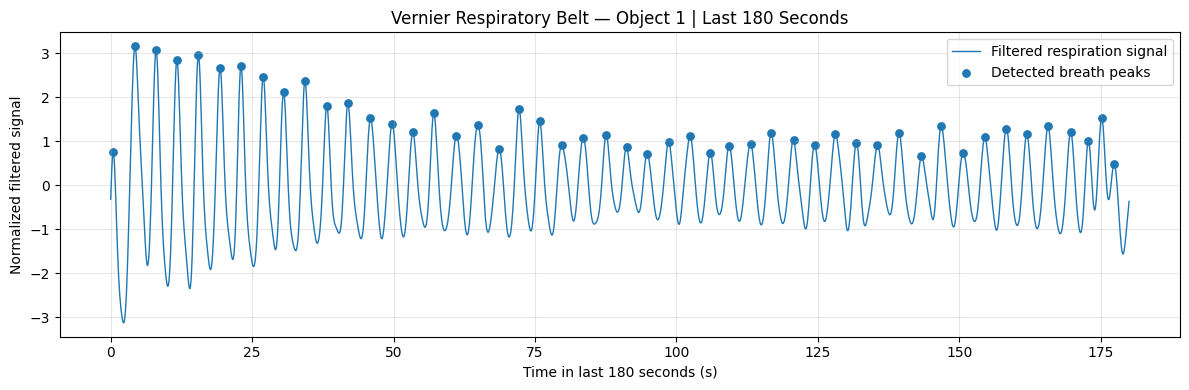

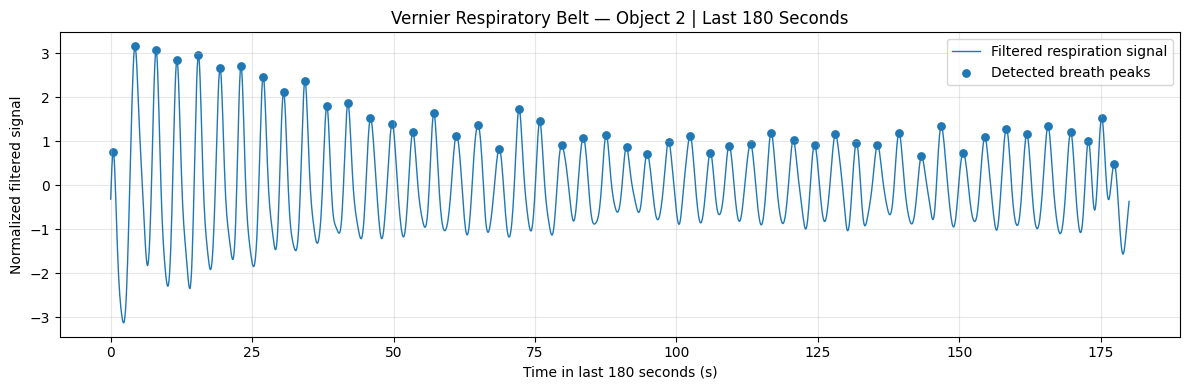

In [ ]:
# ============================================================
# 9. PLOT SINYAL RESPIRASI 3 MENIT TERAKHIR
# ============================================================

for df_cut, detail, name in [
    (df_v1_cut, detail_1, NAMA_OBJECT_1),
    (df_v2_cut, detail_2, NAMA_OBJECT_2)
]:
    peaks = detail["peaks"]
    y = detail["y_filtered_norm"]

    plt.figure(figsize=(12, 4))
    plt.plot(df_cut["Time_cut_s"], y, linewidth=1.0, label="Filtered respiration signal")
    plt.scatter(
        df_cut["Time_cut_s"].iloc[peaks],
        y[peaks],
        s=28,
        marker="o",
        label="Detected breath peaks"
    )
    plt.xlabel("Time in last 180 seconds (s)")
    plt.ylabel("Normalized filtered signal")
    plt.title(f"Vernier Respiratory Belt — {name} | Last 180 Seconds")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


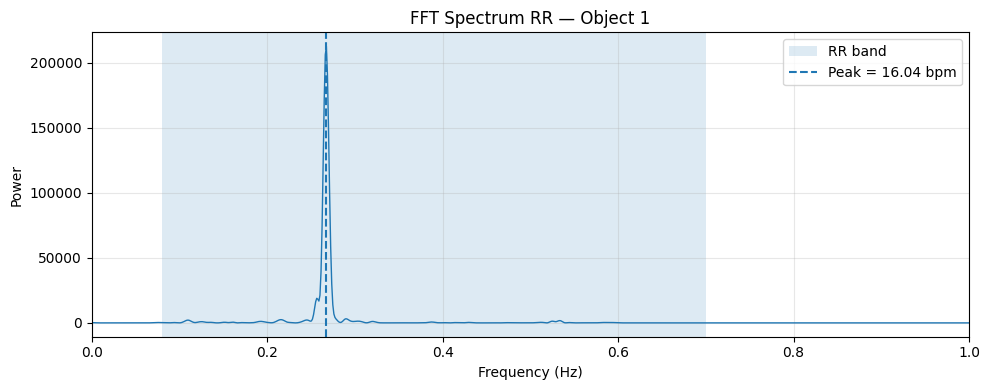

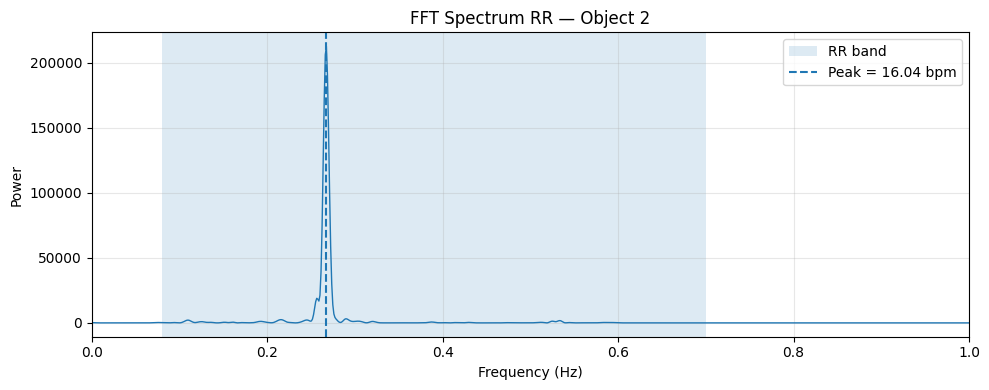

In [ ]:
# ============================================================
# 10. PLOT FFT RESPIRASI
# ============================================================

for detail, summary, name in [
    (detail_1, summary_1, NAMA_OBJECT_1),
    (detail_2, summary_2, NAMA_OBJECT_2)
]:
    f = detail["freq"]
    p = detail["power"]

    plt.figure(figsize=(10, 4))
    plt.plot(f, p, linewidth=1.0)
    plt.axvspan(RR_MIN_HZ, RR_MAX_HZ, alpha=0.15, label="RR band")
    plt.axvline(summary["FFT_Peak_Hz"], linestyle="--", label=f"Peak = {summary['RR_FFT_Last180_bpm']} bpm")
    plt.xlim(0, 1.0)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Power")
    plt.title(f"FFT Spectrum RR — {name}")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


## Cara Membandingkan dengan RR Radar

Setelah nilai RR Vernier didapat, bandingkan dengan RR radar menggunakan:

\[
Error = |RR_{Radar} - RR_{Vernier}|
\]

\[
Error(\%) = \frac{|RR_{Radar} - RR_{Vernier}|}{RR_{Vernier}} \times 100
\]

\[
Accuracy(\%) = 100 - Error(\%)
\]

Nilai Vernier yang disarankan sebagai ground truth utama:

```text
RR_PeakCount_Last180_bpm
```

Nilai FFT dapat dipakai sebagai pembanding tambahan:

```text
RR_FFT_Last180_bpm
```
